# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from mm1_infrastructure import MM1Infrastructure
from network_application import NetworkAwareApplication
from NetworkSimulation import NetworkSimulation
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [2]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

In [ ]:
from eclypse.placement.strategies import RandomStrategy

print("1. Setting up Infrastructure...")
infra = MM1Infrastructure("IoT_Network")

nodi_infrastruttura = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for nodo in nodi_infrastruttura:
    infra.add_node(nodo)


# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_physical_link("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_physical_link("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_physical_link("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_physical_link("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_physical_link("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_physical_link("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_physical_link("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMS:
# Packet Size = 1500 Byte -> Service Time su 10Mbps = 1.2 ms
# Rate = 1 pkt / tick.
# We send every a 0.5ms, but we're busy 1.2ms -> congestion at node R3!
app.add_flow("Sensor", "Cloud", packet_size_bytes=1500, packets_per_tick=1)


print("3. Initializing Simulation...")
sim = NetworkSimulation(infra)

strategy = RandomStrategy(seed=42)
sim.register(app, placement_strategy=strategy)

# Execution
df = sim.run_network_ticks(duration_ticks=100, tick_duration_s=0.0005)

print("Simulation completed!")

1. Setting up Infrastructure...
--- Configuration of Routing Tables (OSPF simulation) ---
Routing tables installed on all nodes.
2. Setting up Application (Video Stream)...
Add edge flow Sensor->Cloud: 1 pkt/tick, size 1500B
3. Initializing Simulation...
17:55:40.358 | WARNING | SimulationConfig - Manual simulation required!
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 'R3', 'Cloud']
['Sensor', 'Gateway', 'R1', 

In [4]:
df

,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops_Count,Hops_Details
0,1,1,,Sensor,Cloud,0.0000,0.003210,3.210170,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
1,2,2,,Sensor,Cloud,0.0005,0.008160,7.659975,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
2,3,3,,Sensor,Cloud,0.0010,0.008477,7.477403,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
3,4,4,,Sensor,Cloud,0.0015,0.010231,8.731149,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
4,5,5,,Sensor,Cloud,0.0020,0.010334,8.333674,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
...,...,...,...,...,...,...,...,...,...,...
95,96,96,,Sensor,Cloud,0.0475,0.103782,56.281851,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
96,97,97,,Sensor,Cloud,0.0480,0.105500,57.500386,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
97,98,98,,Sensor,Cloud,0.0485,0.107592,59.092046,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."
98,99,99,,Sensor,Cloud,0.0490,0.108371,59.370633,4,"[{'hop': 'Sensor->Gateway', 'queue': 0.0, 'arr..."


[Result] Final Queue Delay: 58.34 ms


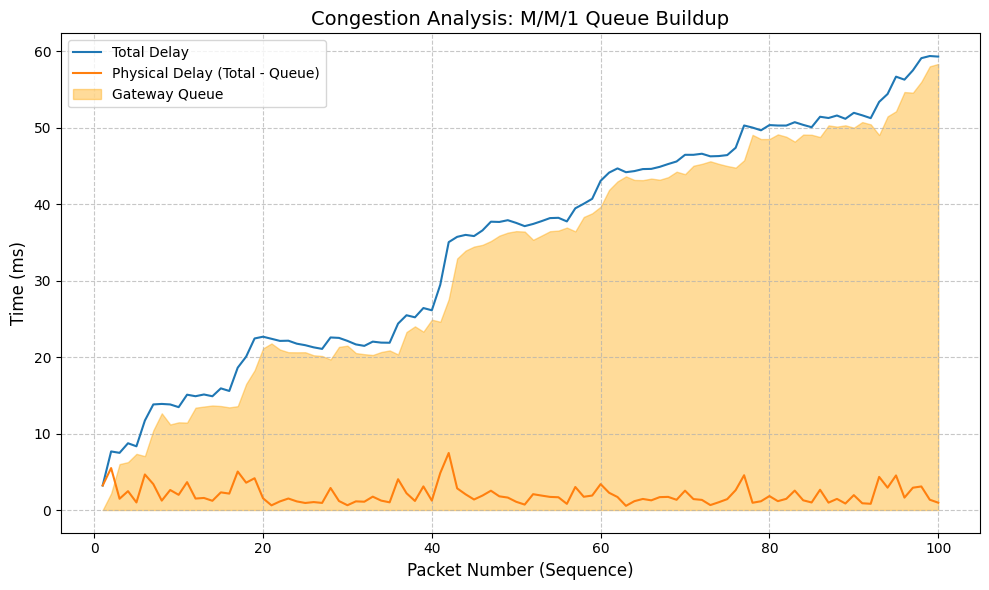

In [5]:
import matplotlib.pyplot as plt

def extract_hop_queue(hops_list, node_pattern):
    """
    Searches the hop list for a link containing 'node_pattern'
    and returns the queue in ms.
    """
    if not isinstance(hops_list, list): return 0.0
    
    for hop in hops_list:
        # Check if the pattern (e.g. "Gateway->Cloud") is in the hop name
        if node_pattern in hop['hop']:
            # hop['queue'] was in seconds, let's convert to ms
            return hop['queue'] * 1000.0 
    return 0.0

# Create the specific "Gateway_Queue_ms" column using .apply()
# This is the "magic" of Pandas: we apply the function row by row.
df['Gateway_Queue_ms'] = df['Hops_Details'].apply(
    lambda x: extract_hop_queue(x, "R3->Cloud")
)

physical_delay = df["Total_Delay_ms"] - df["Gateway_Queue_ms"]

print(f"[Result] Final Queue Delay: {df.iloc[-1]['Gateway_Queue_ms']:.2f} ms")


plt.figure(figsize=(10, 6))

plt.title("Congestion Analysis: M/M/1 Queue Buildup", fontsize=14)
plt.xlabel("Packet Number (Sequence)", fontsize=12)
plt.ylabel("Time (ms)", fontsize=12)

plt.plot(df['Packet_ID'], df['Total_Delay_ms'], label='Total Delay')
plt.plot(df['Packet_ID'], physical_delay, label='Physical Delay (Total - Queue)')
plt.fill_between(df['Packet_ID'], df['Gateway_Queue_ms'], color='orange', alpha=0.4, label='Gateway Queue')
plt.legend(loc="upper left")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()